# Ejercicio 1

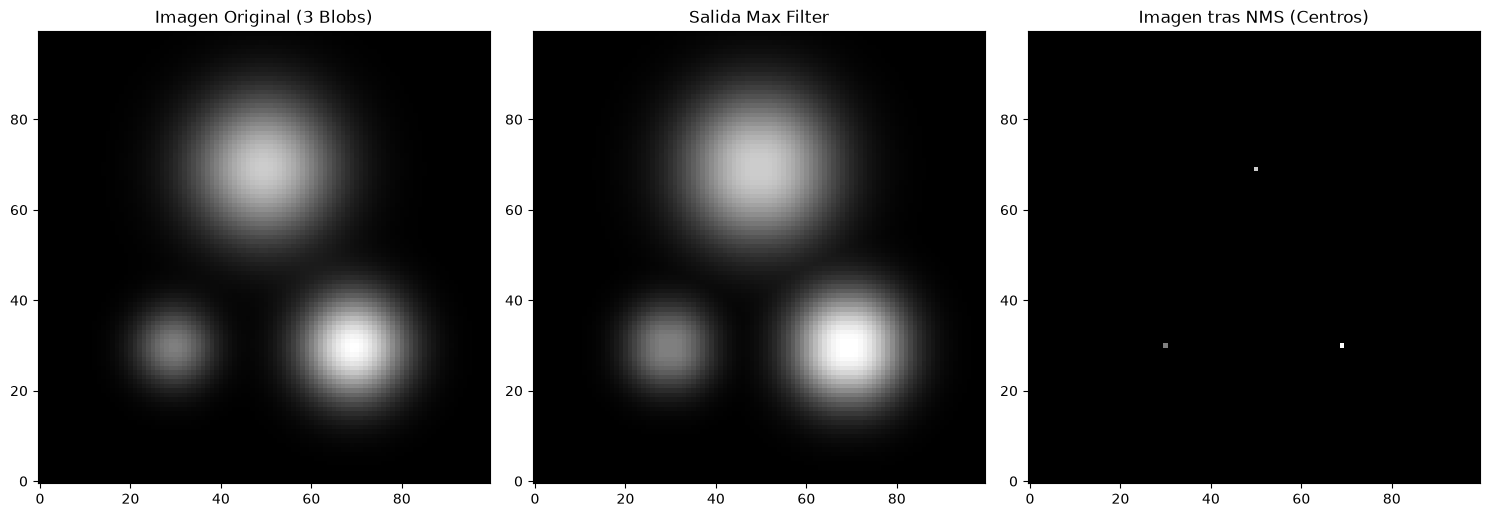

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rank_filter

# 1. Crear una cuadrícula de coordenadas 100x100 que abarque de -10 a 10 en ambos ejes
x_coord = np.linspace(-10, 10, 100)
y_coord = np.linspace(-10, 10, 100)
x, y = np.meshgrid(x_coord, y_coord)

# 2. Función que devuelve una gaussiana 2D con altura máxima unitaria
def gaussian(x, y, x0, y0, sigma):
    # (x0, y0) es el centro y sigma es la desviación estándar en unidades de coordenadas
    return np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))

# 3. Añadir tres blobs gaussianos a una imagen base
image = np.zeros_like(x)

# Centro (-4, -4), sigma=1.2, height=5
image += 5 * gaussian(x, y, -4, -4, 1.2)
# Centro (4, -4), sigma=1.6, height=10
image += 10 * gaussian(x, y, 4, -4, 1.6)
# Centro (0, 4), sigma=2.2, height=8
image += 8 * gaussian(x, y, 0, 4, 2.2)

# 4. Aplicar supresión de no máximos (NMS)
# Obtener el máximo en cada vecindario 3x3
max_filter_output = rank_filter(image, rank=-1, size=3)

# Comparar y retener solo los píxeles iguales al máximo del vecindario (el resto a cero)
image_nms = np.where(image == max_filter_output, image, 0)

# Mostrar la imagen original, la salida del filtro máximo y la imagen tras NMS
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap='gray', origin='lower')
axes[0].set_title('Imagen Original (3 Blobs)')

axes[1].imshow(max_filter_output, cmap='gray', origin='lower')
axes[1].set_title('Salida Max Filter')

axes[2].imshow(image_nms, cmap='gray', origin='lower')
axes[2].set_title('Imagen tras NMS (Centros)')

plt.tight_layout()
plt.show()

# Ejercicio 2

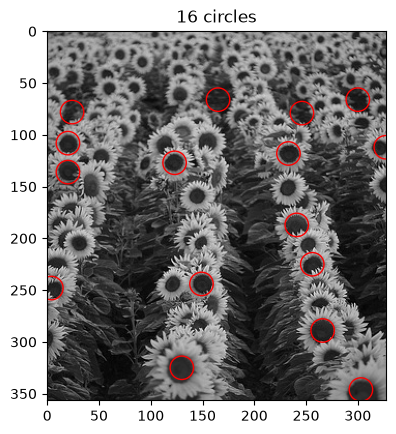

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_laplace, rank_filter
from skimage import io, color
# Importamos la función desde tu archivo local
from show_all_circles import show_all_circles

# 1. Cargar imagen y convertir a escala de grises [0, 1]
# rgb2gray de scikit-image automáticamente escala los valores entre 0 y 1
img_rgb = io.imread('sunflowers.jpg')
img_gray = color.rgb2gray(img_rgb)

# 2. Elegir sigma para los girasoles más grandes (radio en píxeles)
sigma = 8

# 3. Filtrar la imagen usando el filtro LoG
# Multiplicamos por sigma^2 para la normalización de la escala
log_response = (sigma ** 2) * gaussian_laplace(img_gray, sigma=sigma)

# 4. Aplicar thresholding a la imagen filtrada
# Ajustamos este valor a prueba y error. 0.03 funciona bien para empezar.
threshold = 0.15
log_thresholded = np.where(log_response > threshold, log_response, 0)

# 5. Realizar Supresión de No Máximos (NMS) 2D
max_filter_output = rank_filter(log_thresholded, rank=-1, size=3)
nms_output = np.where(log_thresholded == max_filter_output, log_thresholded, 0)

# 6. Extraer coordenadas para graficar
# np.nonzero encuentra los índices de los elementos distintos de cero (los centros detectados)
# Devuelve una tupla con (filas, columnas), que corresponde a (cy, cx)
cy, cx = np.nonzero(nms_output)

# Calcular el radio aproximado del blob a partir de sigma
rad = np.ones_like(cx) * sigma * np.sqrt(2)

# 7. Mostrar resultados
show_all_circles(img_gray, cx, cy, rad, color='r')

# Ejercicio 3

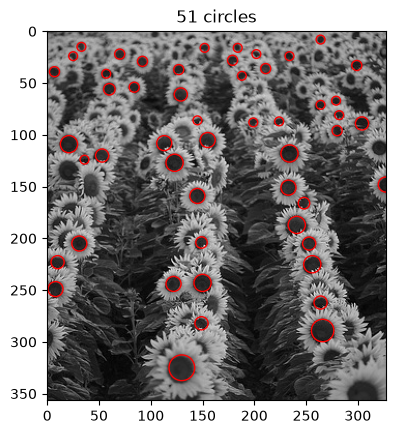

In [15]:
# 1. Definir los parámetros del espacio de escala
sigma_0 = 3.0  # Tamaño inicial para atrapar los girasoles más lejanos
K = 5.0        # Factor multiplicador total (al final llegaremos a un sigma ~ 15)
S = 12         # Número de muestras (calcularemos 12 capas/imágenes distintas)

h, w = img_gray.shape

# Crear un volumen 3D vacío (capas, alto, ancho) para almacenar todas las respuestas
response_volume = np.zeros((S, h, w))
# Arreglo para guardar el sigma exacto usado en cada capa (lo usaremos para calcular el radio final)
sigmas = np.zeros(S)

# 2. Construir el espacio de escala iterando sobre S
for s in range(S):
    # Ecuación dada en las instrucciones:
    sigma_s = sigma_0 * (K ** (s / S))
    sigmas[s] = sigma_s
    
    # Filtrar con normalización de escala (multiplicando por sigma^2)
    log_response = (sigma_s ** 2) * gaussian_laplace(img_gray, sigma=sigma_s)
    
    # Guardar la respuesta 2D en la capa correspondiente del volumen 3D
    response_volume[s] = log_response

# 3. Supresión de No Máximos (NMS) en 3D dentro del volumen completo
# Al pasarle un array 3D, size=3 automáticamente evalúa un vecindario de 3x3x3
max_volume = rank_filter(response_volume, rank=-1, size=3)

# 4. Encontrar los picos locales absolutos que también superen el umbral de ruido
# Un umbral ligeramente más alto ayuda a limpiar sombras irrelevantes
threshold = 0.23
peaks = (response_volume == max_volume) & (response_volume > threshold)

# 5. Extraer las coordenadas 3D de los blobs detectados
# np.nonzero ahora devuelve 3 arreglos: (capa_s, coord_y, coord_x)
s_idx, cy, cx = np.nonzero(peaks)

# Calcular el radio para cada blob detectado usando el sigma de la capa en la que sobrevivió
rad = sigmas[s_idx] * np.sqrt(2)

# 6. Mostrar el resultado final
show_all_circles(img_gray, cx, cy, rad, color='r')